In [1]:
import os
from getpass import getpass
from urllib.parse import quote

REPO_URL = "https://github.com/williamsnunezp/prediccion-atenciones-medicas-salud.git"
REPO_DIR = "/content/prediccion-atenciones-medicas-salud"

token = os.getenv("GITHUB_TOKEN")
if token is None:
    token = getpass("GitHub token (deja vacío si el repo es público o ya fue cargado): ").strip()

if token:
    token = quote(token, safe="")
    clone_url = REPO_URL.replace("https://", f"https://{token}@")
else:
    clone_url = REPO_URL

cloned = False
if not os.path.exists(REPO_DIR):
    !git clone {clone_url} {REPO_DIR}
    cloned = True
else:
    print("Ya existe:", REPO_DIR)

print(os.listdir(REPO_DIR))

if cloned:
    print('Preparando entorno...')
    !mkdir -p /etc/OpenCL/vendors && echo "libnvidia-opencl.so.1" > /etc/OpenCL/vendors/nvidia.icd
    %pip install -q optuna


GitHub token (deja vacío si el repo es público o ya fue cargado): ··········
Cloning into '/content/prediccion-atenciones-medicas-salud'...
remote: Enumerating objects: 417, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 417 (delta 55), reused 106 (delta 24), pack-reused 270 (from 1)
Receiving objects: 100% (417/417), 89.95 MiB | 11.38 MiB/s, done.
Resolving deltas: 100% (166/166), done.
['articles', '.vscode', '.gitignore', 'notebooks', 'requirements.txt', 'data', 'README.md', '.git']
Preparando entorno...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.9 MB/s eta 0:00:00


# **Fase 4: Modelado - Comparación de modelos con balanceo de clases**

### Arquitectura del pipeline

```
Dataset (412,579 registros, 10 features)
    │
    ├── Para cada seed en [42, 123]:
    │       │
    │       ├── train_test_split (85%/15%, stratify, seed=N)
    │       │
    │       ├── TRAIN ──► StratifiedKFold (n_splits=1)
    │       │       │
    │       │       └── Fold 1: Preprocesar → Balanceo (4 técnicas) → Optuna (10 trials)
    │       │
    │       ├── Reentrenar con mejores params en TRAIN completo balanceado
    │       │
    │       └── TEST (15%) → Evaluar SIN balanceo
    │
    └── Agregar resultados de ambos seeds → mean ± std global
```

### Componentes clave

| Componente | Configuración |
|------------|---------------|
| **Modelos** | XGBoost, LightGBM (API nativa, GPU CUDA) |
| **Balanceo** | SMOTETomek, SMOTEENN, NearMiss-1, IHT |
| **Optimización** | Optuna (TPE Sampler, 10 trials por combinación) |
| **Métrica objetivo** | ROC-AUC (optimización) / Recall (evaluación final) |
| **Preprocesamiento** | MinMaxScaler (numéricas) + OrdinalEncoder (categóricas) |
| **Semillas** | [42, 123] (2 seeds) |
| **Folds por seed** | 1 (StratifiedKFold, n_splits=6, usa 1) |
| **Total balanced datasets** | 8 (2 seeds × 4 técnicas × 1 fold) |
| **Hold-out** | 15% estratificado por semilla |

In [2]:
import os
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import islice
#import cupy as cp

from IPython.display import display
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import NearMiss, InstanceHardnessThreshold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

In [3]:
ruta_csv_x = os.path.join(REPO_DIR, "data", "factures.csv")
ruta_csv_y = os.path.join(REPO_DIR, "data", "target.csv")

tipos_x = {
    "especialidad": "category",
    "citas_previas": "category",
    "mes_cita": "category",
    "presencial_remoto": "category",
    "edad": "float32",
    "dia_mes_cita": "category",
    "tasa_noshow_previa": "category",
    "seguro": "category",
    "diferencia_dias": "float32",
    "noshow_previos": "category"
}
tipos_y = {
    "atendido": "int"
}

df_x = pd.read_csv(ruta_csv_x,dtype=tipos_x, delimiter=";")
df_y = pd.read_csv(ruta_csv_y, dtype=tipos_y)

df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412579 entries, 0 to 412578
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   especialidad        412579 non-null  category
 1   citas_previas       412579 non-null  category
 2   mes_cita            412579 non-null  category
 3   presencial_remoto   412579 non-null  category
 4   edad                412579 non-null  float32 
 5   dia_mes_cita        412579 non-null  category
 6   tasa_noshow_previa  412579 non-null  category
 7   seguro              412579 non-null  category
 8   diferencia_dias     412579 non-null  float32 
 9   noshow_previos      412579 non-null  category
dtypes: category(8), float32(2)
memory usage: 6.7 MB


In [4]:
fixed_params = {
    'XGB': {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'subsample': 0.9,
        'device': 'cuda',
        'max_bin': 63,
    },
    'LGBM': {
        'objective': 'binary',
        'device': 'gpu',
        'metric': 'auc',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'min_child_weight': 1e-3,
        # 'n_jobs': -1,
        'max_bin': 63,
        'subsample': 0.9,
        'verbosity': -1,
    }
}

smote_dict = {
    "SMOTETK": lambda rs: SMOTETomek(sampling_strategy="minority", n_jobs=-1, random_state=rs),
    "SMOTEENN": lambda rs: SMOTEENN(sampling_strategy="minority", random_state=rs),
    "NM-1": lambda rs: NearMiss(version=1, sampling_strategy="majority", n_jobs=-1),
    "IHT": lambda rs: InstanceHardnessThreshold(estimator=LogisticRegression(random_state=rs, solver='lbfgs', max_iter=150), sampling_strategy="majority", random_state=rs, n_jobs=-1)
    # Podemos usar un estimador para IHT, pero lo dejamos sin especificar para que use el predeterminado (RandomForestClassifier)
    # Otra opcion es usar un estimador de regresión logística : estimator=LogisticRegression(random_state=rs, solver='lbfgs', max_iter=150).
}

def preprocesar(X_tr,X_vl):
    scaler = MinMaxScaler()
    X_tr_num = scaler.fit_transform(X_tr.select_dtypes(include=['float32']))
    X_vl_num = scaler.transform(X_vl.select_dtypes(include=['float32']))

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr_cat = encoder.fit_transform(X_tr.select_dtypes(include=['category']))
    X_vl_cat = encoder.transform(X_vl.select_dtypes(include=['category']))

    X_tr_proc = np.hstack([X_tr_num, X_tr_cat])
    X_vl_proc = np.hstack([X_vl_num, X_vl_cat])

    return X_tr_proc, X_vl_proc

def get_param_space(nombre_modelo, trial):

    if nombre_modelo == 'XGB':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
            'max_depth': trial.suggest_int('max_depth', 4, 14),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
        }
    elif nombre_modelo == 'LGBM':

        max_depth = trial.suggest_int("max_depth", 4, 13)

        return {
            'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
            'max_depth': max_depth,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        }

def predict_model(_modelo, X_tr_bal, y_tr_bal, X_vl_proc, params_nativos, n_rounds, semilla_seleccionada, calcular_train=False):
    params = {**fixed_params[_modelo], 'random_state': semilla_seleccionada, **params_nativos}
    if _modelo == 'XGB':
        # 2. Crear las matrices de datos usando QuantileDMatrix
        df_tr_bal_dm = xgb.QuantileDMatrix(X_tr_bal, label=y_tr_bal, max_bin=63)
        df_vl_bal_dm = xgb.QuantileDMatrix(X_vl_proc, max_bin=63)

        # 3. Entrenar usando la API nativa de bajo nivel
        modelo = xgb.train(params, df_tr_bal_dm, num_boost_round=n_rounds)

        # 4. Predecir
        if calcular_train:
            y_train_prob = modelo.predict(df_tr_bal_dm)
            y_train_pred = (y_train_prob >= 0.5).astype(int)
        else:
            y_train_prob = None
            y_train_pred = None
        y_test_prob = modelo.predict(df_vl_bal_dm)
        y_test_pred = (y_test_prob >= 0.5).astype(int)

    elif _modelo == 'LGBM':

        # 2. Crear el contenedor nativo de LightGBM
        df_lgb_tr = lgb.Dataset(X_tr_bal, label=y_tr_bal, free_raw_data=False)

        # 3. Entrenar usando la API nativa de bajo nivel
        modelo = lgb.train(params, df_lgb_tr, num_boost_round=n_rounds)

        # 4. Predecir
        if calcular_train:
            y_train_prob = modelo.predict(X_tr_bal)
            y_train_pred = (y_train_prob >= 0.5).astype(int)
        else:
            y_train_prob = None
            y_train_pred = None
        y_test_prob = modelo.predict(X_vl_proc)
        y_test_pred = (y_test_prob >= 0.5).astype(int)

    return y_train_pred, y_train_prob, y_test_pred, y_test_prob


In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Diccionarios para guardar datos y mejores hiperparametros
mejores_hiperparametros = {}

seeds = [42, 123]
N_SPLITS = 1
N_TRIALS = 10

modelos_nombres = ['XGB', 'LGBM']

# ─── Almacena AUC por combinación (across seeds) para calcular mean ± std ───
auc_por_combinacion = {}

# ─── Busqueda de hiperparametros con Optuna ───
for nombre_smote in smote_dict.keys():
    for nombre_modelo in modelos_nombres:
        auc_values = []

        for semilla in seeds:
            # 1. Train/test split para esta semilla
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                df_x, df_y, test_size=0.15, random_state=semilla, stratify=df_y
            )

            # 2. Preprocesar folds
            folds_preprocesados = []
            kf = StratifiedKFold(n_splits=6, shuffle=True, random_state=semilla)

            for fold_idx, (train_idx, val_idx) in enumerate(islice(kf.split(X_train_val, y_train_val), N_SPLITS)):
                X_tr = X_train_val.iloc[train_idx].copy()
                X_vl = X_train_val.iloc[val_idx].copy()
                y_tr = y_train_val.iloc[train_idx].squeeze().copy()
                y_vl = y_train_val.iloc[val_idx].squeeze().copy()

                X_tr_proc, X_vl_proc = preprocesar(X_tr, X_vl)

                folds_preprocesados.append({
                    'X_tr_proc': X_tr_proc,
                    'X_vl_proc': X_vl_proc,
                    'y_tr': y_tr,
                    'y_vl': y_vl
                })

            # 3. Balancear folds
            folds_balanceados = {}
            smote = smote_dict[nombre_smote](semilla)

            for fold_data in folds_preprocesados:
                X_tr_bal, y_tr_bal = smote.fit_resample(fold_data['X_tr_proc'], fold_data['y_tr'])

                folds_balanceados.setdefault(nombre_smote, []).append({
                    'X_tr_bal': X_tr_bal,
                    'y_tr_bal': y_tr_bal,
                    'X_vl_proc': fold_data['X_vl_proc'],
                    'y_vl': fold_data['y_vl']
                })

            # 4. Optuna
            t_inicio = time.time()

            def objective(trial, _modelo=nombre_modelo, _smote_name=nombre_smote, _seed=semilla):
                params = get_param_space(_modelo, trial)
                auc_scores = []

                params_nativos = params.copy()
                n_rounds = params_nativos.pop('n_estimators', 100)

                folds = folds_balanceados[_smote_name]

                for fold_data in folds:
                    _, _, _, y_test_prob = predict_model(
                        _modelo, fold_data['X_tr_bal'], fold_data['y_tr_bal'],
                        fold_data['X_vl_proc'], params_nativos, n_rounds, _seed,calcular_train=False
                    )

                    auc = roc_auc_score(fold_data['y_vl'], y_test_prob)
                    auc_scores.append(auc)

                trial.set_user_attr("fold_auc", auc_scores)
                return np.mean(auc_scores)

            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=semilla))
            study.optimize(objective, n_trials=N_TRIALS, catch=(Exception,), show_progress_bar=False)

            best_trial = study.best_trial
            best_params = best_trial.params
            best_fold_auc = best_trial.user_attrs["fold_auc"]
            best_auc = best_trial.value

            t_fin = time.time()
            tiempo_total = t_fin - t_inicio

            # Guardar AUC para promedio global
            auc_values.append(best_auc)

            # Guardar mejores hiperparametros
            mejores_hiperparametros.setdefault(semilla, {}).setdefault(nombre_smote, {})[nombre_modelo] = best_params

            print(
                f"{nombre_smote:8s} | {nombre_modelo:5s} | seed {semilla:<4} | "
                f"fold 01 | AUC={best_auc:.4f} | params={best_params}"
            )

        # Línea global: mean ± std de ambos seeds
        mean_auc = np.mean(auc_values)
        std_auc = np.std(auc_values)

        print(
            f"{nombre_smote:8s} | {nombre_modelo:5s} | seeds   | "
            f"mean AUC={mean_auc:.4f} ± {std_auc:.4f} | "
            f"Tiempo={tiempo_total:.1f}s\n"
        )

SMOTETK  | XGB   | seed 42   | fold 01 | AUC=0.7081 | params={'n_estimators': 765, 'max_depth': 12, 'learning_rate': 0.015837031559118753}
SMOTETK  | XGB   | seed 123  | fold 01 | AUC=0.7102 | params={'n_estimators': 841, 'max_depth': 11, 'learning_rate': 0.026491494542849877}
SMOTETK  | XGB   | seeds   | mean AUC=0.7092 ± 0.0011 | Tiempo=50.9s

SMOTETK  | LGBM  | seed 42   | fold 01 | AUC=0.7066 | params={'max_depth': 7, 'n_estimators': 1161, 'learning_rate': 0.05395030966670229}
SMOTETK  | LGBM  | seed 123  | fold 01 | AUC=0.7027 | params={'max_depth': 12, 'n_estimators': 980, 'learning_rate': 0.040834149143808396}
SMOTETK  | LGBM  | seeds   | mean AUC=0.7047 ± 0.0020 | Tiempo=220.9s

SMOTEENN | XGB   | seed 42   | fold 01 | AUC=0.7029 | params={'n_estimators': 745, 'max_depth': 7, 'learning_rate': 0.04091220574443785}
SMOTEENN | XGB   | seed 123  | fold 01 | AUC=0.7003 | params={'n_estimators': 714, 'max_depth': 7, 'learning_rate': 0.05358579858873842}
SMOTEENN | XGB   | seeds   | m

# **Fase 5: Evaluación - Análisis de resultados**

### Resultados en TEST (15% hold-out, 2 seeds: 42, 123)

| Combinación | Accuracy | Precision (C1) | Recall (C1) | Precision (C0) | Recall (C0) | ROC AUC |
|-------------|----------|----------------|-------------|----------------|-------------|---------|
| IHT + XGB | 0.4749 ± 0.0004 | 0.3041 ± 0.0007 | **0.8097 ± 0.0036** | 0.8451 ± 0.0022 | 0.3591 ± 0.0007 | 0.6366 ± 0.0023 |
| IHT + LGBM | 0.4747 ± 0.0031 | 0.3040 ± 0.0012 | **0.8096 ± 0.0011** | 0.8449 ± 0.0009 | 0.3589 ± 0.0045 | 0.6371 ± 0.0032 |
| NM-1 + XGB | 0.4986 ± 0.0034 | 0.2914 ± 0.0006 | 0.6641 ± 0.0060 | 0.7916 ± 0.0005 | 0.4414 ± 0.0067 | 0.5526 ± 0.0001 |
| NM-1 + LGBM | 0.5003 ± 0.0006 | 0.2898 ± 0.0008 | 0.6509 ± 0.0025 | 0.7878 ± 0.0012 | 0.4412 ± 0.0067 | 0.5508 ± 0.0017 |
| SMOTEENN + XGB | 0.7279 ± 0.0039 | 0.4679 ± 0.0079 | 0.4280 ± 0.0028 | 0.8316 ± 0.0042 | 0.4471 ± 0.0052 | 0.7013 ± 0.0019 |
| SMOTEENN + LGBM | 0.7283 ± 0.0061 | 0.4686 ± 0.0122 | 0.4262 ± 0.0003 | 0.8328 ± 0.0081 | 0.4463 ± 0.0057 | 0.7000 ± 0.0038 |
| SMOTETK + XGB | 0.7661 ± 0.0005 | 0.6053 ± 0.0039 | 0.2589 ± 0.0023 | 0.9416 ± 0.0015 | 0.3626 ± 0.0015 | 0.7130 ± 0.0013 |
| SMOTETK + LGBM | 0.7646 ± 0.0004 | 0.6057 ± 0.0039 | 0.2412 ± 0.0035 | 0.9457 ± 0.0017 | 0.3450 ± 0.0029 | 0.7037 ± 0.0033 |

> C1 = Clase 1 (NO VINO / inasistencia). C0 = Clase 0 (VINO / asistencia).

### Análisis — Recall (sensibilidad) como métrica principal

**¿Por qué Recall (C1)?** En el contexto hospitalario, un falso negativo (predecir que el paciente sí asistirá cuando en realidad no asiste) tiene un costo elevado: el turno se pierde sin posibilidad de reasignación. El Recall mide qué proporción de inasistencias reales logra detectar el modelo. Priorizar Recall(C1) significa "ante la duda, marcar como no-show" para poder intervenir (recordatorios, sobrebooking, etc.).

| Combinación ganadora | Recall (C1) | Trade-off |
|----------------------|-------------|-----------|
| **IHT + XGB** | **0.8097 ± 0.0036** | Baja accuracy (0.4749), muchas falsas alarmas |
| IHT + LGBM | 0.8096 ± 0.0011 | Misma situación, menor varianza entre semillas |

> Las combinaciones con IHT logran el mayor Recall (~0.81), detectando el 81% de las inasistencias reales. El costo es una Accuracy baja (~0.47) y muchas falsas alarmas (Precision C1 ~0.30), lo cual es aceptable cuando el costo de no detectar una inasistencia supera el costo de una intervención innecesaria.

**Contexto — Precision y ROC AUC**

> Como referencia complementaria, SMOTETK+XGB obtiene la mayor Precision(C1) (0.6053) y ROC AUC (0.7130), pero su Recall(C1) es bajo (0.2589), detectando solo el 26% de inasistencias. Esta combinación prioriza reducir falsas alarmas a costa de perder inasistencias reales.


In [24]:
filas_train = []
filas_test = []
filas_balanceo = []
predicciones = {}

for semilla in seeds:
    # 1. Train/test split para esta semilla
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        df_x, df_y, test_size=0.15, random_state=semilla, stratify=df_y
    )

    # 2. Preprocesar
    X_train_val_proc, X_test_proc = preprocesar(X_train_val, X_test)

    # 3. Para cada combinación smote × modelo
    for nombre_smote, smote_factory in smote_dict.items():
        smote = smote_factory(semilla)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_val_proc, y_train_val)

        n_orig = len(y_train_val)
        n_bal = len(y_train_bal)
        cambio_pct = ((n_bal - n_orig) / n_orig) * 100

        filas_balanceo.append({
            'Semilla': semilla,
            'Técnica': nombre_smote,
            'Original': n_orig,
            'Balanceado': n_bal,
            'Cambio%': cambio_pct
        })

        for nombre_modelo in modelos_nombres:
            params = mejores_hiperparametros[semilla][nombre_smote][nombre_modelo]
            params_nativos = params.copy()
            n_rounds = params_nativos.pop('n_estimators', 100)

            y_train_pred, y_train_prob, y_test_pred, y_test_prob = predict_model(
                nombre_modelo, X_train_bal, y_train_bal, X_test_proc,
                params_nativos, n_rounds, semilla, calcular_train=True
            )

            predicciones[f'seed{semilla}_{nombre_smote}_{nombre_modelo}'] = {
                'y_test': y_test,
                'y_pred': y_test_pred,
                'y_proba': y_test_prob
            }

            filas_train.append({
                'Semilla': semilla,
                'SMOTE': nombre_smote,
                'Modelo': nombre_modelo,
                'Accuracy': accuracy_score(y_train_bal, y_train_pred),
                'Precision_C1': precision_score(y_train_bal, y_train_pred),
                'Recall_C1': recall_score(y_train_bal, y_train_pred),
                'Precision_C0': precision_score(y_train_bal, y_train_pred, pos_label=0),
                'Recall_C0': recall_score(y_train_bal, y_train_pred, pos_label=0),
                'F1_Score': f1_score(y_train_bal, y_train_pred),
                'F1_macro': f1_score(y_train_bal, y_train_pred, average='macro'),
                'ROC_AUC': roc_auc_score(y_train_bal, y_train_prob),
            })

            filas_test.append({
                'Semilla': semilla,
                'SMOTE': nombre_smote,
                'Modelo': nombre_modelo,
                'Accuracy': accuracy_score(y_test, y_test_pred),
                'Precision_C1': precision_score(y_test, y_test_pred),
                'Recall_C1': recall_score(y_test, y_test_pred),
                'Precision_C0': precision_score(y_test, y_test_pred, pos_label=0),
                'Recall_C0': recall_score(y_test, y_test_pred, pos_label=0),
                'F1_Score': f1_score(y_test, y_test_pred),
                'F1_macro': f1_score(y_test, y_test_pred, average='macro'),
                'ROC_AUC': roc_auc_score(y_test, y_test_prob),
            })

df_train = pd.DataFrame(filas_train)
df_test = pd.DataFrame(filas_test)
df_balanceo = pd.DataFrame(filas_balanceo)

# ─── Tabla de balanceo ───
print("=" * 60)
print("  DISTRIBUCIÓN DE BALANCEO")
print("=" * 60)
display(df_balanceo)

# ─── Resultados train (ambas semillas) ───
print(f"\n{'='*60}")
print(f"  RESULTADOS TRAIN (ambas semillas)")
print(f"{'='*60}")
display(df_train.sort_values(['Semilla', 'Recall_C1'], ascending=[True, False])
        .style.highlight_max(subset=['Recall_C1','Recall_C0'], color='lightcoral'))

# ─── Resultados test (ambas semillas) ───
print(f"\n{'='*60}")
print(f"  RESULTADOS TEST (ambas semillas)")
print(f"{'='*60}")
display(df_test.sort_values(['Semilla', 'Recall_C1'], ascending=[True, False])
        .style.highlight_max(subset=['Recall_C1','Recall_C0'], color='lightcoral'))

# ─── Resultados globales (mean ± std) ───
print(f"\n{'='*60}")
print(f"  RESULTADOS GLOBALES (mean ± std)")
print(f"{'='*60}")
metric_cols = ['Accuracy', 'Precision_C1', 'Recall_C1', 'Precision_C0', 'Recall_C0', 'F1_Score', 'F1_macro', 'ROC_AUC']
df_global = df_test.groupby(['SMOTE', 'Modelo'])[metric_cols].agg(['mean', 'std'])
display(df_global.sort_values(('Recall_C1', 'mean'), ascending=False))


  DISTRIBUCIÓN DE BALANCEO


,Semilla,Técnica,Original,Balanceado,Cambio%
0,42,SMOTETK,350692,485134,38.336204
1,42,SMOTEENN,350692,262123,-25.255495
2,42,NM-1,350692,180254,-48.600481
3,42,IHT,350692,180254,-48.600481
4,123,SMOTETK,350692,485326,38.390953
5,123,SMOTEENN,350692,263365,-24.901338
6,123,NM-1,350692,180254,-48.600481
7,123,IHT,350692,180254,-48.600481



  RESULTADOS TRAIN (ambas semillas)


,Semilla,SMOTE,Modelo,Accuracy,Precision_C1,Recall_C1,Precision_C0,Recall_C0,F1_Score,F1_macro,ROC_AUC
2,42,SMOTEENN,XGB,0.897273,0.952527,0.864917,0.836574,0.941320,0.906611,0.896236,0.962999
3,42,SMOTEENN,LGBM,0.897643,0.953592,0.864527,0.836384,0.942725,0.906878,0.896627,0.963127
6,42,IHT,XGB,0.897423,0.975633,0.815205,0.841301,0.979640,0.888233,0.896724,0.938683
7,42,IHT,LGBM,0.893878,0.972954,0.810279,0.837456,0.977476,0.884197,0.893131,0.932261
0,42,SMOTETK,XGB,0.872289,0.957185,0.779442,0.813984,0.965135,0.859218,0.871178,0.950347
4,42,NM-1,XGB,0.827371,0.888213,0.749010,0.783016,0.905733,0.812694,0.826305,0.915614
1,42,SMOTETK,LGBM,0.852224,0.946273,0.746853,0.790916,0.957595,0.834819,0.850565,0.917205
5,42,NM-1,LGBM,0.757975,0.807835,0.676989,0.722015,0.838961,0.736647,0.756377,0.838441
10,123,SMOTEENN,XGB,0.903275,0.957190,0.870892,0.844004,0.947185,0.912004,0.902314,0.966755
11,123,SMOTEENN,LGBM,0.889841,0.946182,0.857368,0.828432,0.933874,0.899588,0.888793,0.956172



  RESULTADOS TEST (ambas semillas)


,Semilla,SMOTE,Modelo,Accuracy,Precision_C1,Recall_C1,Precision_C0,Recall_C0,F1_Score,F1_macro,ROC_AUC
6,42,IHT,XGB,0.475221,0.304622,0.812260,0.846691,0.358640,0.443076,0.473467,0.638289
7,42,IHT,LGBM,0.476885,0.304856,0.808802,0.845556,0.362076,0.442807,0.474921,0.639320
4,42,NM-1,XGB,0.501010,0.291803,0.659855,0.791289,0.446066,0.404658,0.487588,0.552630
5,42,NM-1,LGBM,0.500735,0.290325,0.652625,0.788590,0.448197,0.401874,0.486713,0.551968
2,42,SMOTEENN,XGB,0.730638,0.473520,0.430053,0.808925,0.834609,0.450741,0.636154,0.702682
3,42,SMOTEENN,LGBM,0.732561,0.477266,0.426344,0.808637,0.838480,0.450370,0.636829,0.702663
0,42,SMOTETK,XGB,0.765783,0.602531,0.260484,0.786188,0.940564,0.363724,0.610100,0.712047
1,42,SMOTETK,LGBM,0.764878,0.608494,0.238730,0.782414,0.946871,0.342922,0.599872,0.706036
15,123,IHT,LGBM,0.472571,0.303161,0.810311,0.844284,0.355748,0.441241,0.470908,0.634810
14,123,IHT,XGB,0.474655,0.303621,0.807168,0.843552,0.359641,0.441259,0.472772,0.634985



  RESULTADOS GLOBALES (mean ± std)


Accuracy           Precision_C1           Recall_C1  \
                     mean       std         mean       std      mean   
SMOTE    Modelo                                                        
IHT      XGB     0.474938  0.000400     0.304121  0.000708  0.809714   
         LGBM    0.474728  0.003051     0.304009  0.001198  0.809557   
NM-1     XGB     0.498610  0.003393     0.291392  0.000581  0.664131   
         LGBM    0.500299  0.000617     0.289777  0.000776  0.650865   
SMOTEENN XGB     0.727891  0.003885     0.467912  0.007931  0.428041   
         LGBM    0.728255  0.006090     0.468622  0.012225  0.426155   
SMOTETK  XGB     0.766138  0.000503     0.605277  0.003884  0.258881   
         LGBM    0.764627  0.000354     0.605709  0.003937  0.241182   

                          Precision_C0           Recall_C0            \
                      std         mean       std      mean       std   
SMOTE    Modelo                                                        
IHT      XGB     0.003601     0.845122  0.002219  0.359141  0.000707   
         LGBM    0.001067     0.844920  0.000900  0.358912  0.004475   
NM-1     XGB     0.006046     0.791629  0.000481  0.441357  0.006659   
         LGBM    0.002490     0.787755  0.001181  0.448219  0.000031   
SMOTEENN XGB     0.002845     0.807818  0.001565  0.831608  0.004244   
         LGBM    0.000267     0.807516  0.001585  0.832750  0.008104   
SMOTETK  XGB     0.002267     0.786009  0.000254  0.941597  0.001461   
         LGBM    0.003468     0.782751  0.000476  0.945685  0.001676   

                 F1_Score            F1_macro             ROC_AUC            
                     mean       std      mean       std      mean       std  
SMOTE    Modelo                                                              
IHT      XGB     0.442168  0.001285  0.473119  0.000491  0.636637  0.002336  
         LGBM    0.442024  0.001107  0.472914  0.002838  0.637065  0.003189  
NM-1     XGB     0.405056  0.000563  0.485890  0.002402  0.552592  0.000054  
         LGBM    0.401014  0.001215  0.486182  0.000750  0.550791  0.001665  
SMOTEENN XGB     0.447084  0.005172  0.633312  0.004019  0.701315  0.001933  
         LGBM    0.446345  0.005693  0.633139  0.005219  0.699962  0.003821  
SMOTETK  XGB     0.362644  0.001527  0.609720  0.000537  0.712994  0.001339  
         LGBM    0.344979  0.002909  0.600758  0.001253  0.703723  0.003270

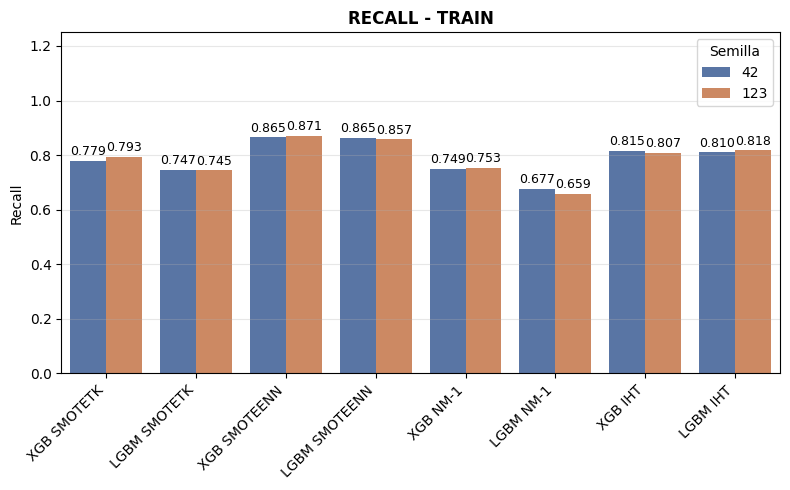

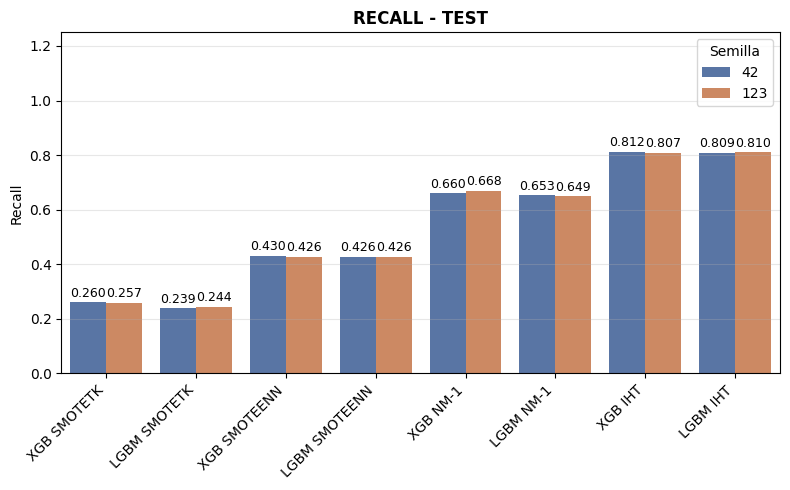

In [25]:
df_train_plot = df_train.copy()
df_train_plot['Combinacion'] = df_train_plot['Modelo'] + ' ' + df_train_plot['SMOTE']

df_test_plot = df_test.copy()
df_test_plot['Combinacion'] = df_test_plot['Modelo'] + ' ' + df_test_plot['SMOTE']

data = {'Train': df_train_plot, 'Test': df_test_plot}
#colores = {'Train': 'steelblue', 'Test': 'coral'}

for titulo, df in data.items():
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df, x='Combinacion', y='Recall_C1',palette=['#4C72B0', '#DD8452'], hue='Semilla', ax=ax)
    ax.set_title(f'RECALL - {titulo.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Recall')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.25)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)
    plt.tight_layout()
    plt.show()

# **Fase 6: Implementación**

### 6.1. Objetivo
Anticipar la probabilidad de inasistencias para optimizar recursos, reducir inasistencias y mejorar la programación de citas. Se implementa un **ensamble orientado a maximizar el Recall de la clase 1 (inasistencias)**.

### 6.2. Modelo seleccionado — Ensamble para maximizar Recall

La combinación IHT + XGB/LGBM obtuvo el mayor Recall(C1) (~0.81), detectando el 81% de las inasistencias reales. Se propone un ensamble de ambos modelos IHT promediando sus probabilidades de predicción.

| Modelo | Balanceo | Recall (C1) | Precision (C1) | ROC AUC |
|--------|----------|-------------|----------------|--------|
| XGB | IHT | **0.8097 ± 0.0036** | 0.3041 ± 0.0007 | 0.6366 ± 0.0023 |
| LGBM | IHT | **0.8096 ± 0.0011** | 0.3040 ± 0.0012 | 0.6371 ± 0.0032 |

**Regla de decisión del ensamble:** Se promedian las probabilidades de predicción de ambos modelos (IHT+XGB e IHT+LGBM). Si la probabilidad promedio supera el umbral de 0.5, se predice inasistencia. Promediar las probabilidades suaviza las predicciones individuales y mejora la generalización.

**Uso:** Alertas tempranas, recordatorios intensivos, sobreprogramación inteligente.

---

### 6.3. Arquitectura de despliegue

| Componente | Descripción |
|------------|-------------|
| **Servidor de Modelos** | API REST (FastAPI/Docker) con 2 modelos serializados (IHT+XGB, IHT+LGBM) |
| **Pipeline de Predicción** | Preprocesamiento → Predicción IHT+XGB + IHT+LGBM → Promedio de probabilidades → Umbral 0.5 → Alerta |
| **Base de Datos** | Historial de predicciones, resultados reales y métricas del ensamble |

**Modo de operación:**
- **Tiempo real** (al agendar cita): Predicción inmediata para alertas
- **Batch** (diario/semanal): Reportes de inasistencias detectadas

### 6.4. Automatización de intervenciones

| Nivel de riesgo | Acción |
|-----------------|--------|
| Alto (< 50% prob. asistencia) | Llamada + SMS + reasignación prioritaria |
| Medio (50-70%) | SMS + WhatsApp |

### 6.5. Monitoreo continuo

- **Métricas**: Recall (principal), Precision, F1, AUC
- **Operacional**: Tiempo respuesta API (<100ms), uptime (>99.5%)
- **Data drift**: Alerta si distribución se desvía >2 desviaciones estándar
- **Reentrenamiento**: Completo cada 6 meses, fine-tuning cada 3 meses

### 6.6. Roadmap (6 meses)

| Fase | Período | Actividades |
|------|---------|-------------|
| **Preparación** | Mes 1 | Serializar 2 modelos, crear API, documentación |
| **Piloto** | Mes 2-3 | Desplegar ensamble, comparar rendimiento real |
| **Expansión** | Mes 4-5 | Integrar con HIS/EHR, automatizar intervenciones |
| **Operación** | Mes 6+ | Monitoreo 24/7, evaluación de impacto |

### 6.7. Métricas de éxito

| Tipo | Métrica | Meta |
|------|---------|------|
| **Adopción** | Citas con predicción | > 95% |
| **Impacto** | Reducción inasistencia | > 15% |
| **Técnico** | Recall ensamble | > 80% |
| **Técnico** | Uptime | > 99.5% |

### 6.8. Consideraciones éticas y legales

- **Protección de datos**: Ley N° 29733 + GDPR
- **Seguridad**: Encriptación, RBAC, auditoría
- **Uso ético**: Transparencia, decisión humana final
- **Consentimiento**: Política de privacidad + opción opt-out


  SMOTETK | XGB  (TEST) — Seed 42
              precision    recall  f1-score   support

     Clase 0     0.7862    0.9406    0.8565     45982
     Clase 1     0.6025    0.2605    0.3637     15905

    accuracy                         0.7658     61887
   macro avg     0.6944    0.6005    0.6101     61887
weighted avg     0.7390    0.7658    0.7298     61887


  SMOTETK | LGBM  (TEST) — Seed 42
              precision    recall  f1-score   support

     Clase 0     0.7824    0.9469    0.8568     45982
     Clase 1     0.6086    0.2388    0.3430     15905

    accuracy                         0.7649     61887
   macro avg     0.6955    0.5928    0.5999     61887
weighted avg     0.7377    0.7649    0.7248     61887


  SMOTEENN | XGB  (TEST) — Seed 42
              precision    recall  f1-score   support

     Clase 0     0.8089    0.8346    0.8216     45982
     Clase 1     0.4735    0.4301    0.4507     15905

    accuracy                         0.7306     61887
   macro avg     0.64

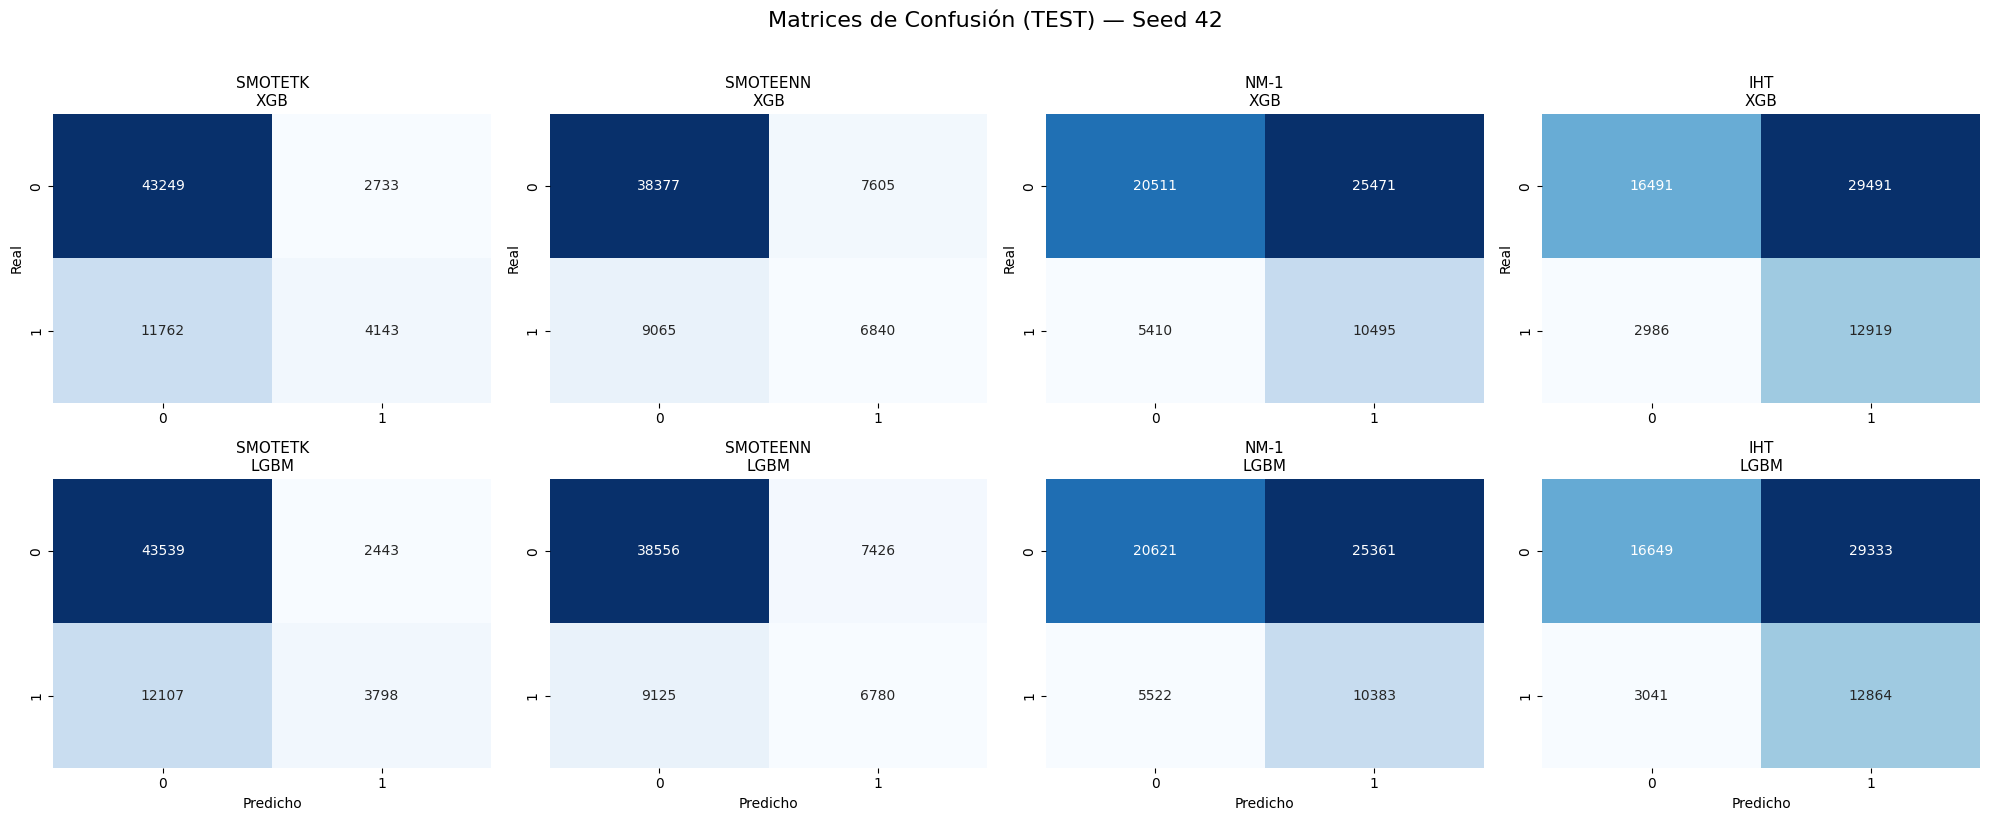

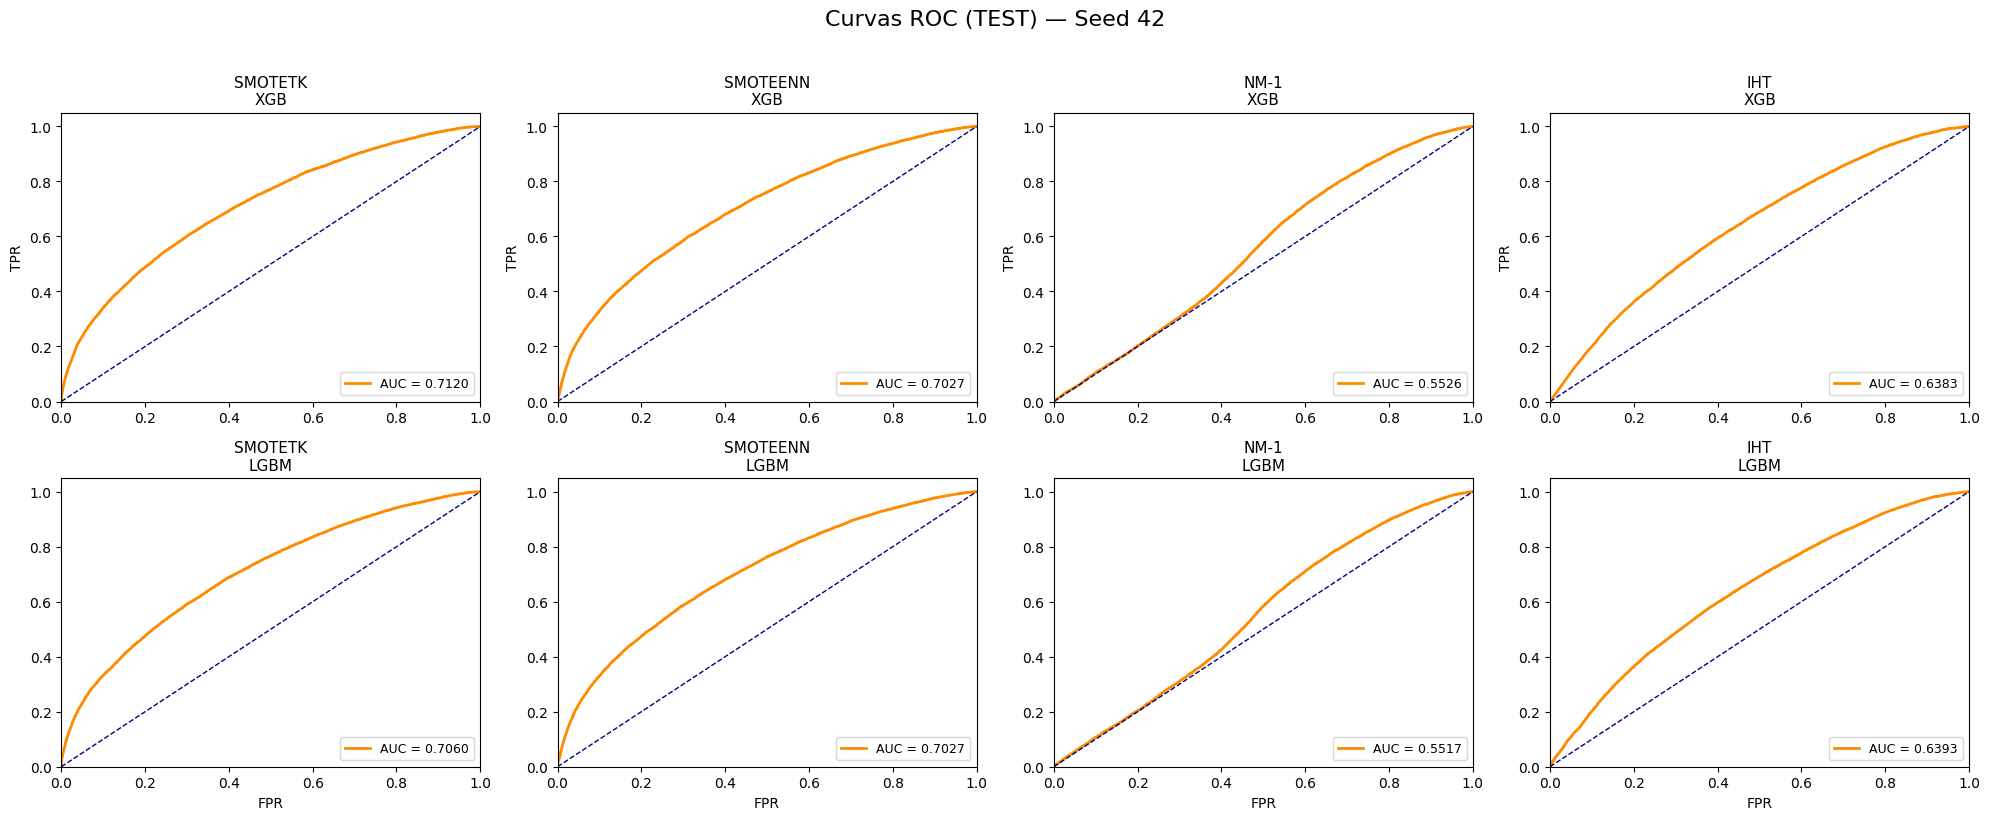

In [17]:
import sys
sys.path.insert(0, os.path.join(REPO_DIR, "notebooks"))
from model_evaluator import ModelEvaluator

evaluator = ModelEvaluator(predicciones, seed=42)
evaluator.plot_all()